# Quoting Engine

A market maker quotes a bid ask based on a spread centered on the fair value point from heston.

The order arrivals will be modeled with a poisson process. 

The Avellaneda-Stoikov framework is used to derive optimal bid/ask quotes by computing a reservation price adjusted for inventory risk, then placing a spread symmetrically around it.

Outputs: bid/ask quotes over time, inventory path, and P&L attribution.

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.stats import norm

In [2]:
# grab r0 from vasicek params

with open("../data/vasicek_params.json") as f:
    params = json.load(f)

r0 = params['r0']

# market snapshot - April 24th, 2026 close
S0 = 86.71 # TLT spot price
fair_value = 2.50 # placeholder Heston call price
sigma = 0.15 # placeholder implied vol

print(f"r0: {r0}")
print(f"S0: {S0}")
print(f"fair_value: {fair_value}")
print(f"sigma: {sigma}")

r0: 0.0369
S0: 86.71
fair_value: 2.5
sigma: 0.15


### Avellaneda-Stoikov

Academic standard for options market making. The core idea: you don't quote symmetrically around fair value - you skew your quotes based on your inventory to manage risk.

Three formulas:
$$r_{price} = \text{fair\_value} - \text{inventory} \cdot \gamma \cdot \sigma^2 \cdot (T - t)$$

$$\text{spread} = \gamma \cdot \sigma^2 \cdot (T-t) + \frac{2}{\gamma} \ln\left(1 + \frac{\gamma}{\kappa_{MM}}\right)$$

$$\text{bid} = r_{price} - \frac{\text{spread}}{2}, \quad \text{ask} = r_{price} + \frac{\text{spread}}{2}$$

Parameters:
* $\gamma$      : Our risk aversion. Higher = wider spreads, more aggressive inventory skew
* $\kappa_{MM}$ : Rate at which orders arrive. Higher = tighter spreads (more flow = less need to widen)
* $T$           : Expiration of the option
* $t$           : current time (start at 0)
* inventory     : Start at zero

In [3]:
# parameters
T = 21/365
t = 0.0
gamma = 0.1
kappa_MM = 20   # 20 orders per year
inventory = 0

# calculations
r_price = fair_value - inventory * gamma * sigma**2 * (T-t)

spread = gamma * sigma**2 * (T-t) + (2/gamma) * np.log(1 + (gamma/kappa_MM))

bid = r_price - (spread/2)
ask = r_price + (spread/2)

print(r_price, spread,bid, ask)


2.5 0.09988028227557387 2.450059858862213 2.549940141137787


### Discrete Delta Hedging
Delta measures the sensitivity of our option's value to a `$1` move in TLT. A delta of 0.5 means if TLT moves up `$1`, our option gains `$0.50`.

As market makers we don't want to take a directional bet on TLT — we just 
want to capture spread. So we hedge delta by trading TLT shares to offset 
our option exposure, keeping us approximately direction-neutral.

We hedge discretely — once per day — rather than continuously. This is 
realistic since continuous hedging is impossible in practice and incurs 
infinite transaction costs. The gap between our discrete hedge and the 
theoretically perfect continuous hedge is called **delta hedge slippage**, 
which we will track as part of our P&L attribution.

Delta is calculated using the Black-Scholes formula — not for pricing, 
but as a translation tool to convert our Heston fair value into a 
hedgeable Greeks exposure.

In [4]:
def bs_delta(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + sigma **2 / 2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

print(bs_delta(S0, S0, r0, sigma, T))


0.5306866423728474


### TLT Price Path Simulation
We simulate TLT prices over the 21-day window using Geometric Brownian Motion (GBM), 
with our calibrated Vasicek spot rate r0 as the drift. This allows our delta hedge 
to respond to actual price moves rather than a static spot price.

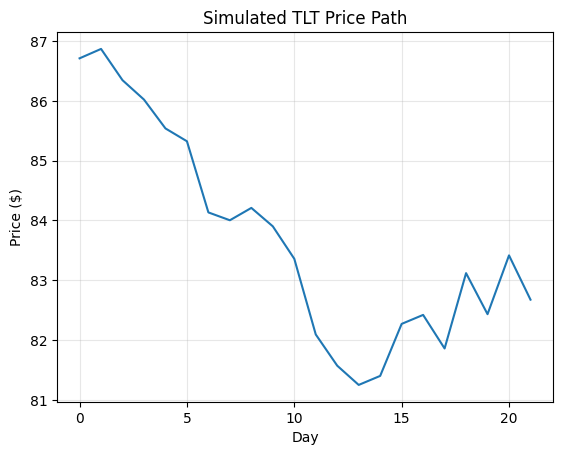

In [5]:
def simulate_tlt_path(S0, r0, sigma, T_days, seed = None):
    if seed is not None:
        np.random.seed(seed)
    dt = 1/365
    prices = [S0]
    for i in range(T_days):
        dW = np.random.normal(0, np.sqrt(dt))
        S_new = prices[-1] * np.exp((r0 - 0.5 * sigma**2) * dt + sigma * dW)
        prices.append(S_new)
    return np.array(prices)

tlt_path = simulate_tlt_path(S0, r0, sigma, T_days=21)

# plot TLT path
plt.plot(tlt_path)
plt.title('Simulated TLT Price Path')
plt.xlabel('Day')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)
plt.show()

### Poisson Order Arrival Simulation
We simulate order flow over the 21-day life of the option. At each daily time step, buyers and sellers arrive randomly via independent Poisson processes with arrival rate `kappa_MM`. Not every arrival results in a fill — fill probability decays exponentially with distance of the quote from fair value. This captures adverse selection: the further our quote is from fair value, the less likely we get hit.

We track inventory, P&L, and re-calculate reservation price and spread at each step to reflect inventory skew.

Final inventory:     1
Bids filled:         1
Asks filled:         0
Cash P&L:            -2.4501
Mark-to-market P&L: 2.5000
Hedge P&L:           1.3312
Total P&L:           1.3811
Current TLT shares:  -0.0000


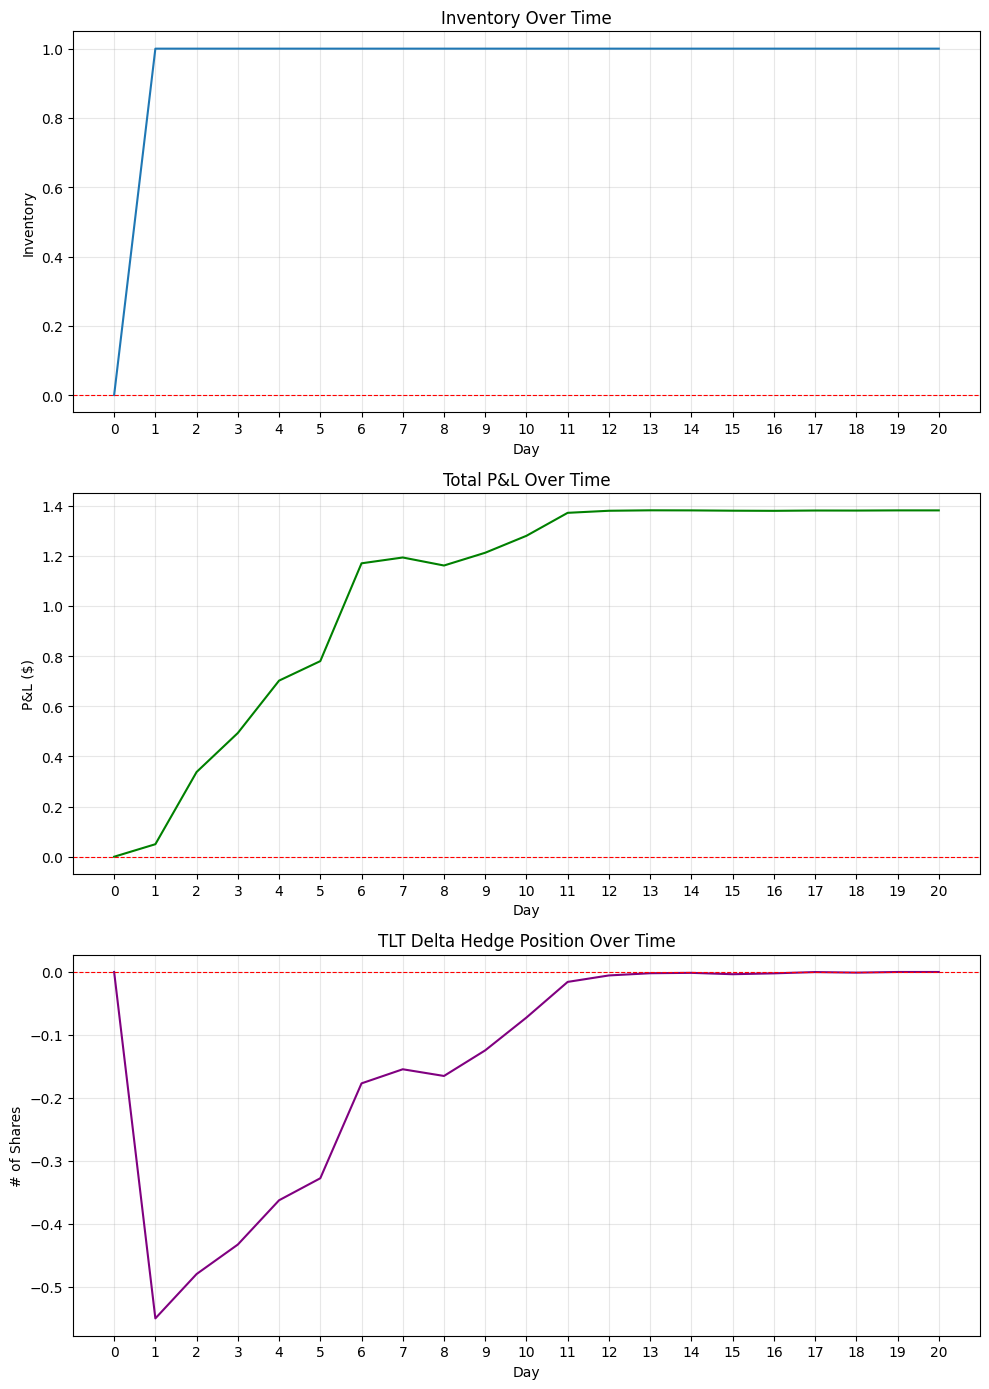

In [11]:
# initialize tracking variables
inventory = 0          # current net position (+ = long, - = short)
bids_filled = 0        # number of times a seller hit our bid (we bought)
asks_filled = 0        # number of times a buyer hit our ask (we sold)
pnl = 0                # cumulative cash P&L from spread capture
inventory_track = []   # daily inventory snapshots for plotting
pnl_track = []         # daily total P&L snapshots for plotting
shares_track = []      # daily TLT share position snapshots for plotting
current_shares = 0     # how many TLT shares we currently hold as our delta hedge
hedge_pnl = 0          # cumulative P&L from TLT share position moving

# hard inventory limit — stop quoting on a side if we hit this threshold
max_inventory = 3

# main simulation loop — one day at a time over 21 day option window
for day in range(21):
    t = day / 365  # current time in years

    # --- QUOTING ---
    # A-S reservation price skews our mid based on inventory
    # long inventory → shade quotes lower to attract sellers
    r_price = fair_value - inventory * gamma * sigma**2 * (T - t)
    spread = gamma * sigma**2 * (T - t) + (2/gamma) * np.log(1 + (gamma/kappa_MM))
    bid = r_price - (spread/2)
    ask = r_price + (spread/2)

    # --- ORDER ARRIVALS ---
    # buyers and sellers arrive randomly each day via Poisson process
    # kappa_MM is annual so we scale to daily
    buyers = np.random.poisson(kappa_MM / 365)
    sellers = np.random.poisson(kappa_MM / 365)

    # --- FILL PROBABILITY ---
    # arriving orders don't always fill — probability decays with distance from fair value
    # this captures adverse selection: informed traders only fill us when our price is off
    prob_bid = np.exp(-kappa_MM * (fair_value - bid))
    prob_ask = np.exp(-kappa_MM * (ask - fair_value))

    # --- FILLS ---
    # ask side: buyer wants to buy from us — only allow if not at short limit
    if inventory > -max_inventory:
        if buyers > 0 and np.random.rand() < prob_ask:
            inventory -= 1    # we sold a contract
            asks_filled += 1
            pnl += ask        # cash inflow at ask price

    # bid side: seller wants to sell to us — only allow if not at long limit
    if inventory < max_inventory:
        if sellers > 0 and np.random.rand() < prob_bid:
            inventory += 1    # we bought a contract
            bids_filled += 1
            pnl -= bid        # cash outflow at bid price

    # --- DELTA HEDGE ---
    # calculate BS delta using today's simulated TLT price
    # target_shares is how many TLT shares we need to hold to be delta neutral
    # negative sign because we're offsetting our option exposure
    delta = bs_delta(tlt_path[day], S0, r0, sigma, T - t)
    target_shares = -inventory * delta

    # mark-to-market our existing share position before rebalancing
    # captures gain/loss from TLT moving since yesterday
    if day > 0:
        hedge_pnl += current_shares * (tlt_path[day] - tlt_path[day - 1])

    # rebalance hedge to new target
    current_shares = target_shares

    # --- END OF DAY SNAPSHOT ---
    inventory_track.append(inventory)
    pnl_track.append(pnl + inventory * fair_value + hedge_pnl)
    shares_track.append(current_shares)

# --- FINAL P&L ATTRIBUTION ---
mtm_pnl = inventory * fair_value       # mark-to-market value of remaining option inventory
total_pnl = pnl + mtm_pnl + hedge_pnl # spread capture + inventory MTM + hedge gains

# store daily results in dataframe
tracking_df = pd.DataFrame({'Inventory': inventory_track, 'Total P&L': pnl_track, 'TLT Shares': shares_track})

print(f"Final inventory:     {inventory}")
print(f"Bids filled:         {bids_filled}")
print(f"Asks filled:         {asks_filled}")
print(f"Cash P&L:            {pnl:.4f}")
print(f"Mark-to-market P&L: {mtm_pnl:.4f}")
print(f"Hedge P&L:           {hedge_pnl:.4f}")
print(f"Total P&L:           {total_pnl:.4f}")
print(f"Current TLT shares:  {current_shares:.4f}")

# --- PLOTS ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 14))

ax1.plot(range(21), inventory_track)
ax1.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax1.set_title('Inventory Over Time')
ax1.set_xlabel('Day')
ax1.set_ylabel('Inventory')
ax1.set_xticks(range(21))
ax1.grid(True, alpha=0.3)

ax2.plot(range(21), pnl_track, color='green')
ax2.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax2.set_title('Total P&L Over Time')
ax2.set_xlabel('Day')
ax2.set_ylabel('P&L ($)')
ax2.set_xticks(range(21))
ax2.grid(True, alpha=0.3)

ax3.plot(range(21), shares_track, color='purple')
ax3.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax3.set_title('TLT Delta Hedge Position Over Time')
ax3.set_xlabel('Day')
ax3.set_ylabel('# of Shares')
ax3.set_xticks(range(21))
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()